In [107]:
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# from scipy import stats
from scipy.stats import pearsonr, spearmanr, pointbiserialr, ttest_ind, shapiro, normaltest, mannwhitneyu

sys.path.append(str(Path.cwd().parents[3]))
from utils.helpers import load_data

In [108]:
# Define consistent color palette for the entire analysis
COLOR_COMBINED = '#6B8CAE'    # Steel blue for combined data
COLOR_MALE = '#4A90E2'        # Bright blue for male students
COLOR_FEMALE = '#E85A9B'      # Pink for female students
COLOR_BOXPLOT = '#2C3E50'     # Dark blue-grey for boxplots

# Gender color mapping for easy reference
GENDER_COLORS = {
    'M': COLOR_MALE,
    'F': COLOR_FEMALE,
    'Male': COLOR_MALE,
    'Female': COLOR_FEMALE,
    'Combined': COLOR_COMBINED
}

# Exam Performance Analysis: Gender and Time Patterns

This notebook analyzes exam performance differences between male and female students, focusing on:

- **Performance differences** between genders with statistical testing
- **Time completion patterns** by gender
- **Effect size** and practical significance of observed differences
- **Time-performance correlations** and their relationship to gender

## 1. Data Loading

The cleaned exam data is loaded from the CSV file.

In [109]:
df = load_data("../data/cleaned_data/IN1020_2024_cleaned_data.csv")
#extract exam name from file name 
exam_name = Path("../data/cleaned_data/IN1020_2024_cleaned_data.csv").stem.split("_cleaned_data")[0]

Data loaded successfully from ../data/cleaned_data/IN1020_2024_cleaned_data.csv


## Overview

In [110]:
print(f"This notebook provides a comprehensive analysis of exam performance for {exam_name}, comparing male and female students.")

This notebook provides a comprehensive analysis of exam performance for IN1020_2024, comparing male and female students.


## 2. Data Preparation

We'll prepare separate datasets for different analyses:
- **df_male**: Data about total score among male students
- **df_female**: Data about total score among female students
- **df_time**: Data including exam timing information by gender

In [111]:
# Prepare student-level dataset with unique records per student
df_combined = df.groupby('student_id').agg({
    'gender': 'first',
    'total_score': 'first'
}).reset_index()

# Create gender-specific subsets for analysis
df_male = df_combined[df_combined['gender'] == 'M']
df_female = df_combined[df_combined['gender'] == 'F']

# Prepare a subset for exam time analysis
df_time = df.groupby('student_id').agg({
    'exam_start_time': 'first',
    'exam_end_time': 'first',
    'gender': 'first',
    'total_score': 'first',
    'extra_time_mins': 'first',
    'incident_time_mins': 'first'
}).reset_index()

#add column with time taken to complete the exam in minutes
df_time['time_taken'] = round((pd.to_datetime(df_time['exam_end_time']) - pd.to_datetime(df_time['exam_start_time'])).dt.total_seconds() / 60, 2)
df_time = df_time.dropna(subset=['time_taken'])

In [112]:
print("Dataset with only male students:")
df_male.head()

Dataset with only male students:


,student_id,gender,total_score
0,1,M,72.63
2,3,M,75.45
4,5,M,72.28
6,7,M,56.61
8,9,M,69.36


In [113]:
print("Dataset with only female students:")
df_female.head()

Dataset with only female students:


,student_id,gender,total_score
1,2,F,56.71
3,4,F,55.88
5,6,F,73.43
7,8,F,61.29
10,11,F,48.38


In [114]:
print("Dataset with time taken to complete the exam:")
df_time.head()

Dataset with time taken to complete the exam:


,student_id,exam_start_time,exam_end_time,gender,total_score,extra_time_mins,incident_time_mins,time_taken
0,1,2024-12-11 14:01:44,2024-12-11 16:18:42,M,72.63,0,0,136.97
1,2,2024-12-11 14:00:02,2024-12-11 17:52:41,F,56.71,0,0,232.65
2,3,2024-12-11 14:00:03,2024-12-11 17:57:49,M,75.45,0,0,237.77
3,4,2024-12-11 14:00:05,2024-12-11 17:53:27,F,55.88,0,0,233.37
4,5,2024-12-11 14:00:04,2024-12-11 17:23:20,M,72.28,0,0,203.27


---

## 3. Descriptive Statistics

This section presents comprehensive statistical measures for total scores by gender, including:
- Central tendency measures (mean, median, mode)
- Dispersion measures (standard deviation, range, IQR)
- Distribution shape indicators (skewness, kurtosis)
- Gender performance comparison

In [115]:
# Enhanced descriptive statistics table
def calculate_descriptive_stats(data, name):
    """Calculate comprehensive descriptive statistics"""
    stats_dict = {
        'Count': len(data),
        'Mean': round(data.mean(), 2),
        'Median': round(data.median(), 2),
        'Mode': round(data.mode()[0], 2),
        'Std Dev': round(data.std(), 2),
        'Min': round(data.min(), 2),
        'Max': round(data.max(), 2),
        'Q1': round(data.quantile(0.25), 2),
        'Q3': round(data.quantile(0.75), 2),
        'IQR': round(data.quantile(0.75) - data.quantile(0.25), 2),
        'Skewness': round(data.skew(), 3),
        'Kurtosis': round(data.kurtosis(), 3)
    }
    return pd.Series(stats_dict, name=name)

# Create comprehensive statistics table
descriptive_stats = pd.DataFrame([
    calculate_descriptive_stats(df_male['total_score'], 'Male'),
    calculate_descriptive_stats(df_female['total_score'], 'Female')
]).T

print("=== DESCRIPTIVE STATISTICS FOR TOTAL SCORES ===")
print(descriptive_stats)

# Calculate mean difference and percentage difference
if df_male['total_score'].mean() > df_female['total_score'].mean():
    mean_diff = df_male['total_score'].mean() - df_female['total_score'].mean()
    pct_diff = (mean_diff / df_female['total_score'].mean()) * 100
    print(f"\n=== KEY FINDINGS ===")
    print(f"Mean difference (Male - Female): {mean_diff:.2f} points")
    print(f"Percentage difference: {pct_diff:.1f}%")
    print(f"Male performance is higher than female performance")
elif df_female['total_score'].mean() > df_male['total_score'].mean():
    mean_diff = df_female['total_score'].mean() - df_male['total_score'].mean()
    pct_diff = (mean_diff / df_male['total_score'].mean()) * 100
    print(f"\n=== KEY FINDINGS ===")
    print(f"Mean difference (Female - Male): {mean_diff:.2f} points")
    print(f"Percentage difference: {pct_diff:.1f}%")
    print(f"Female performance is higher than male performance")
else:
    print("\n=== KEY FINDINGS ===")
    print("No difference in mean scores between male and female students.")

=== DESCRIPTIVE STATISTICS FOR TOTAL SCORES ===
             Male   Female
Count     311.000  258.000
Mean       66.070   63.440
Median     67.930   66.660
Mode       63.530   42.500
Std Dev    13.330   14.300
Min        27.700   24.480
Max        91.850   90.890
Q1         58.140   53.810
Q3         75.620   74.140
IQR        17.490   20.330
Skewness   -0.656   -0.465
Kurtosis    0.005   -0.308

=== KEY FINDINGS ===
Mean difference (Male - Female): 2.63 points
Percentage difference: 4.1%
Male performance is higher than female performance


### 3.1 Gender Distribution

The following pie chart shows the proportion of male and female students in the exam.

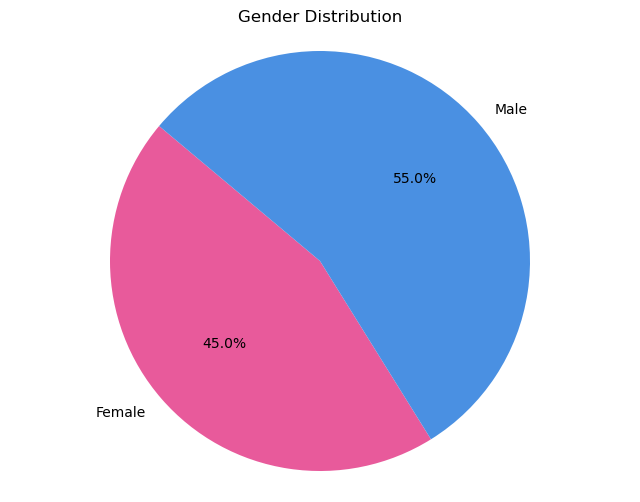

In [116]:
# Gender distribution pie chart
plt.figure(figsize=(8, 6))
# Ensure consistent order: Female first, then Male
gender_counts = df['gender'].value_counts().reindex(['F', 'M'])
plt.pie(gender_counts, autopct='%1.1f%%', 
        colors=[COLOR_FEMALE, COLOR_MALE], 
        startangle=140,
        labels=['Female', 'Male'])
plt.title("Gender Distribution")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

---

## 4. Statistical Analysis

This section performs statistical hypothesis testing to determine if performance differences between genders are statistically significant and practically meaningful.

### 4.1 Score Distribution Visualization

This section visualizes the score distributions for male and female students with key statistical measures overlaid:
- **Red dashed line**: Mean score
- **Green solid line**: Median score
- **Purple shaded area**: ±1 standard deviation from the mean
- **Skewness value**: Indicates distribution shape

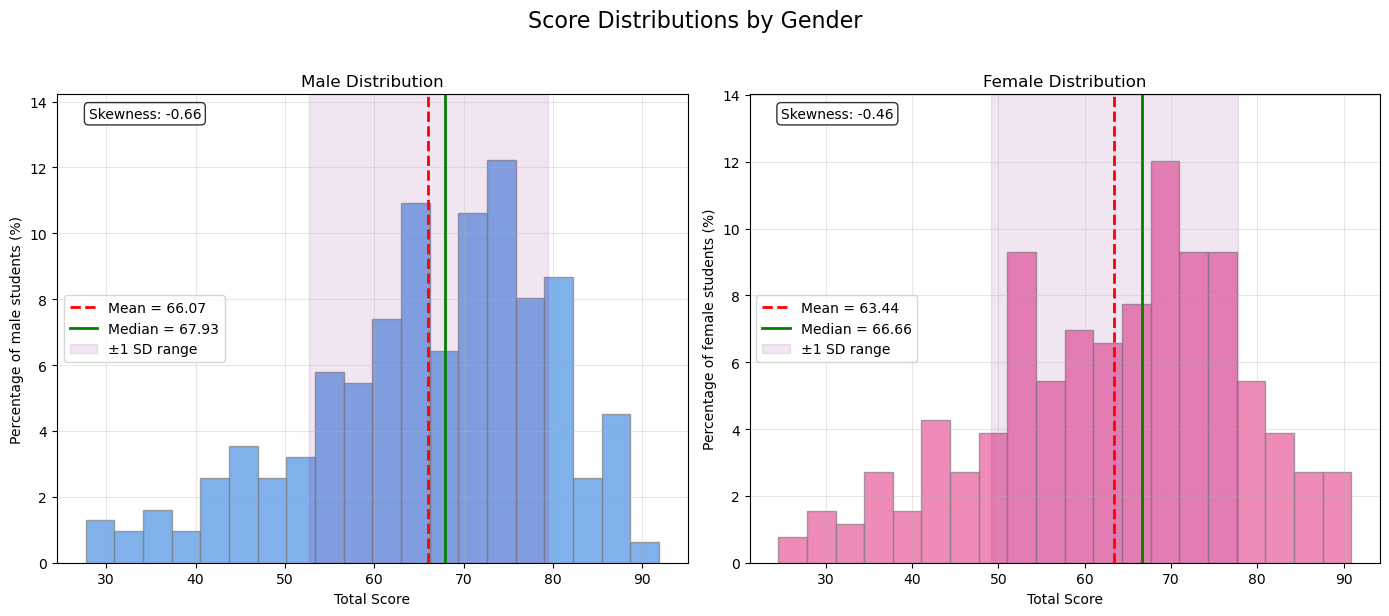

=== DISTRIBUTION SHAPE INTERPRETATION ===
Male: left-skewed (negative skew) (skewness = -0.656)
Female: approximately symmetric (skewness = -0.465)


In [117]:
def plot_enhanced_distributions(df, axes, title, ylabel, color='lightblue'):
    """Create enhanced distribution plots with statistical annotations"""
    mean_val = df['total_score'].mean()
    median_val = df['total_score'].median()
    std_val = df['total_score'].std()
    skew_val = df['total_score'].skew()
    
    total_students = len(df)
    
    # Create histogram with percentage weights
    n, bins, patches = axes.hist(df['total_score'], bins=20, color=color, edgecolor='gray', alpha=0.7, 
             weights=np.ones(len(df))/total_students*100)
    
    # Add statistical lines
    axes.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
    axes.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median = {median_val:.2f}')
    axes.axvspan(mean_val - std_val, mean_val + std_val, color='purple', alpha=0.1, label='±1 SD range')
    
    # Add skewness annotation
    axes.text(0.05, 0.95, f'Skewness: {skew_val:.2f}', transform=axes.transAxes, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes.set_xlabel("Total Score")
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.grid(True, alpha=0.3)
    # Set y-limit to maximum y-value plus 5
    max_y = max(n)
    axes.set_ylim(0, max_y+2)
    axes.legend()

# Create enhanced distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_enhanced_distributions(df_male, axes[0], "Male Distribution", 
                          "Percentage of male students (%)", COLOR_MALE)
plot_enhanced_distributions(df_female, axes[1], "Female Distribution", 
                          "Percentage of female students (%)", COLOR_FEMALE)

plt.suptitle("Score Distributions by Gender", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Interpretation of skewness
print("=== DISTRIBUTION SHAPE INTERPRETATION ===")
for name, data in [("Male", df_male), ("Female", df_female)]:
    skew = data['total_score'].skew()
    if abs(skew) < 0.5:
        shape = "approximately symmetric"
    elif skew > 0.5:
        shape = "right-skewed (positive skew)"
    else:
        shape = "left-skewed (negative skew)"
    print(f"{name}: {shape} (skewness = {skew:.3f})")

### 4.2 Data Distribution & Normality Testing

Before choosing the appropriate statistical test, we need to check if the data follows a normal distribution.

In [118]:
# Unified normality testing function
def test_normality(data, group_name):
    """Perform normality tests and return results based on sample size"""
    n = len(data)
    
    print(f"\n{group_name} (n={n}):")
    
    # Determine which test to use based on sample size
    if n < 20:
        print("  Too little data to run normality tests (n < 20)")
        return False
    
    elif 20 <= n <= 200:
        # Use D'Agostino test for medium sample sizes
        dagostino_stat, dagostino_p = normaltest(data)
        print(f"  D'Agostino test for samples under 200 entities: stat={dagostino_stat:.4f}, p={dagostino_p:.4f}")
        is_normal = dagostino_p > 0.05
        print(f"  Normal distribution: {is_normal}")
        return is_normal
    
    elif 200 < n <= 2000:
        # Use Shapiro-Wilk test for larger sample sizes (up to 2000)
        shapiro_stat, shapiro_p = shapiro(data)
        print(f"  Shapiro-Wilk test for samples between 200 and 2000 entities: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
        is_normal = shapiro_p > 0.05
        print(f"  Normal distribution: {is_normal}")
        return is_normal
    
    else:
        # Sample size too large for Shapiro-Wilk, use D'Agostino-Pearson omnibus test
        print("  Sample size > 2000, using D'Agostino-Pearson omnibus test")
        dagostino_stat, dagostino_p = normaltest(data)
        print(f"  D'Agostino-Pearson test: stat={dagostino_stat:.4f}, p={dagostino_p:.4f}")
        is_normal = dagostino_p > 0.05
        print(f"  Normal distribution: {is_normal}")
        return is_normal

def test_correlation_normality(data1, data2, name1, name2):
    """Test normality of two variables to determine appropriate correlation test"""
    print(f"\nTesting normality for {name1} and {name2}:")
    
    # Test each variable using the unified test_normality function
    var1_normal = test_normality(data1, name1)
    var2_normal = test_normality(data2, name2)
    
    both_normal = var1_normal and var2_normal
    print(f"\nBoth variables normally distributed: {both_normal}")
    return both_normal
        

print("=== NORMALITY TESTS ===")
male_normal = test_normality(df_male['total_score'], "Male")
female_normal = test_normality(df_female['total_score'], "Female")

all_normal = male_normal and female_normal
print(f"\nBoth groups normally distributed: {all_normal}")

=== NORMALITY TESTS ===

Male (n=311):
  Shapiro-Wilk test for samples between 200 and 2000 entities: W=0.9646, p=0.0000
  Normal distribution: False

Female (n=258):
  Shapiro-Wilk test for samples between 200 and 2000 entities: W=0.9762, p=0.0003
  Normal distribution: False

Both groups normally distributed: False


### 4.3 Hypothesis Testing

The following analysis tests whether the observed performance difference between male and female students is statistically significant and calculates effect sizes to determine practical importance.

In [119]:
# Comprehensive statistical testing
def perform_statistical_tests(male_scores, female_scores, use_normality_results=True):
    """Perform relevant statistical tests and calculate effect sizes based on normality assumptions"""
    
    print("=== STATISTICAL HYPOTHESIS TESTING ===")
    print("H0: No difference in mean scores between male and female students")
    print("H1: There is a difference in mean scores between groups")
    print()
    
    # Calculate means and difference for later use
    male_mean = np.mean(male_scores)
    female_mean = np.mean(female_scores)
    mean_diff = male_mean - female_mean
    
    # Determine primary test based on normality (if results available)
    if use_normality_results and 'all_normal' in globals(): # returns a dictionary containing all global variables that exist in the current Python file or environment
        primary_parametric = all_normal
    else:
        primary_parametric = True  # Default to parametric if normality not tested
    
    print(f"Primary approach: {'Parametric' if primary_parametric else 'Non-parametric'} (based on normality test results)")
    print()
    
    # Point-biserial correlation (always calculated as it's distribution-free for correlation interpretation)
    combined_scores = np.concatenate([male_scores, female_scores])
    gender_binary = np.concatenate([np.ones(len(male_scores)), np.zeros(len(female_scores))])
    pb_corr, pb_pval = pointbiserialr(gender_binary, combined_scores)
    
    # Initialize variables for primary test results
    primary_p = None
    primary_effect = None
    primary_test = None
    primary_effect_size = None
    
    if primary_parametric:
        # Run parametric tests
        print("PARAMETRIC APPROACH (Data meets normality assumptions):")
        t_stat, t_pval = ttest_ind(male_scores, female_scores, equal_var=False)
        
        # Cohen's d (effect size for parametric)
        pooled_std = np.sqrt(((len(male_scores)-1)*np.var(male_scores, ddof=1) + 
                              (len(female_scores)-1)*np.var(female_scores, ddof=1)) / 
                             (len(male_scores) + len(female_scores) - 2))
        cohens_d = mean_diff / pooled_std
        
        print(f"  Welch's t-test: t = {t_stat:.4f}, p = {t_pval:.4f}")
        print(f"  Cohen's d: {cohens_d:.4f}")
        
        # Effect size interpretation for Cohen's d
        if abs(cohens_d) < 0.2:
            cohens_effect = "negligible"
        elif abs(cohens_d) < 0.5:
            cohens_effect = "small"
        elif abs(cohens_d) < 0.8:
            cohens_effect = "medium"
        else:
            cohens_effect = "large"
        
        print(f"  Effect size magnitude: {cohens_effect}")
        print(f"  Significant at α=0.05: {t_pval < 0.05}")
        
        # Set primary results
        primary_p = t_pval
        primary_effect = cohens_effect
        primary_test = "Welch's t-test"
        primary_effect_size = f"Cohen's d = {cohens_d:.3f}"
        
        # Store for return
        t_stat_return = t_stat
        t_pval_return = t_pval
        cohens_d_return = cohens_d
        u_stat_return = None
        u_pval_return = None
        rank_biserial_return = None
        rb_effect_return = None
        
    else:
        # Run non-parametric tests
        print("NON-PARAMETRIC APPROACH (Data violates normality assumptions):")
        u_stat, u_pval = mannwhitneyu(male_scores, female_scores, alternative='two-sided')
        
        # Rank-biserial correlation (effect size for non-parametric)
        n1, n2 = len(male_scores), len(female_scores)
        rank_biserial = (2 * u_stat) / (n1 * n2) - 1
        
        print(f"  Mann-Whitney U test: U = {u_stat:.1f}, p = {u_pval:.4f}")
        print(f"  Rank-biserial correlation: {rank_biserial:.4f}")
        
        # Effect size interpretation for rank-biserial correlation
        if abs(rank_biserial) < 0.1:
            rb_effect = "negligible"
        elif abs(rank_biserial) < 0.3:
            rb_effect = "small"
        elif abs(rank_biserial) < 0.5:
            rb_effect = "medium"
        else:
            rb_effect = "large"
        
        print(f"  Effect size magnitude: {rb_effect}")
        print(f"  Significant at α=0.05: {u_pval < 0.05}")
        
        # Set primary results
        primary_p = u_pval
        primary_effect = rb_effect
        primary_test = "Mann-Whitney U test"
        primary_effect_size = f"Rank-biserial r = {rank_biserial:.3f}"
        
        # Store for return
        u_stat_return = u_stat
        u_pval_return = u_pval
        rank_biserial_return = rank_biserial
        rb_effect_return = rb_effect
        t_stat_return = None
        t_pval_return = None
        cohens_d_return = None
    
    print("\nCORRELATION ANALYSIS:")
    print(f"  Point-biserial correlation: r = {pb_corr:.4f}, p = {pb_pval:.4f}")
    print(f"  Variance explained (R²): {pb_corr**2:.4f} ({pb_corr**2*100:.1f}%)")
    
    # Provide interpretation based on which test is primary
    print(f"\nPRIMARY INTERPRETATION:")
    print(f"  Based on {primary_test}:")
    print(f"  Statistical significance: {'Yes' if primary_p < 0.05 else 'No'} (p = {primary_p:.4f})")
    print(f"  Effect size: {primary_effect_size} ({primary_effect})")
    print(f"  Practical significance: {'Yes' if primary_effect != 'negligible' else 'No'}")
    
    # Decision about H0
    if primary_p < 0.05:
        print(f"  Decision: Reject H0 - There is a statistically significant difference between groups")
    else:
        print(f"  Decision: Fail to reject H0 - No statistically significant difference detected")
    
    return {
        't_stat': t_stat_return, 't_pval': t_pval_return,
        'u_stat': u_stat_return, 'u_pval': u_pval_return,
        'pb_corr': pb_corr, 'pb_pval': pb_pval,
        'cohens_d': cohens_d_return, 'cohens_effect': primary_effect if primary_parametric else None,
        'rank_biserial': rank_biserial_return, 'rb_effect': rb_effect_return,
        'primary_parametric': primary_parametric,
        'primary_p': primary_p, 'primary_effect': primary_effect,
        'male_mean': male_mean, 'female_mean': female_mean, 'mean_diff': mean_diff
    }

# Run statistical tests
test_results = perform_statistical_tests(df_male['total_score'], df_female['total_score'])

=== STATISTICAL HYPOTHESIS TESTING ===
H0: No difference in mean scores between male and female students
H1: There is a difference in mean scores between groups

Primary approach: Non-parametric (based on normality test results)

NON-PARAMETRIC APPROACH (Data violates normality assumptions):
  Mann-Whitney U test: U = 44500.5, p = 0.0248
  Rank-biserial correlation: 0.1092
  Effect size magnitude: small
  Significant at α=0.05: True

CORRELATION ANALYSIS:
  Point-biserial correlation: r = 0.0948, p = 0.0237
  Variance explained (R²): 0.0090 (0.9%)

PRIMARY INTERPRETATION:
  Based on Mann-Whitney U test:
  Statistical significance: Yes (p = 0.0248)
  Effect size: Rank-biserial r = 0.109 (small)
  Practical significance: Yes
  Decision: Reject H0 - There is a statistically significant difference between groups


### 4.4 Results Interpretation

The following interpretation explains the statistical findings in accessible language:

In [120]:
# User-friendly explanation of statistical test results
def explain_test_results_for_non_statisticians(test_results):
    """
    Explain statistical test results in plain, accessible language for non-statisticians
    """
    print("UNDERSTANDING YOUR TEST RESULTS")
    print("=" * 70)
    
    # Extract pre-calculated values from test_results
    male_mean = test_results['male_mean']
    female_mean = test_results['female_mean']
    diff = abs(test_results['mean_diff'])
    higher_group = "male" if test_results['mean_diff'] > 0 else "female"
    
    print(f"\n WHAT WE FOUND:")
    print(f"   • Male students averaged: {male_mean:.1f} points")
    print(f"   • Female students averaged: {female_mean:.1f} points") 
    print(f"   • Difference: {diff:.1f} points ({higher_group} students scored higher)")
    
    # Question 1: Is this difference real or just random?
    print(f"\n QUESTION 1: Is this difference REAL or just random chance?")
    
    primary_p = test_results.get('primary_p', 1.0)
    
    if primary_p < 0.001:
        certainty = "extremely confident (99.9%+ certain)"
        explanation = "This is almost definitely a real difference, not random variation."
    elif primary_p < 0.01:
        certainty = "very confident (99%+ certain)"  
        explanation = "This is very likely a real difference, not random variation."
    elif primary_p < 0.05:
        certainty = "confident (95%+ certain)"
        explanation = "This is likely a real difference, not random variation."
    elif primary_p < 0.10:
        certainty = "somewhat uncertain (90% certain)"
        explanation = "This might be a real difference, but there's some uncertainty."
    else:
        certainty = "not confident (less than 90% certain)"
        explanation = "This difference could easily be due to random chance."
    
    print(f"   ANSWER: We are {certainty}")
    print(f"   What this means: {explanation}")
    print(f"   Technical note: p-value = {primary_p:.4f}")
    
    # Question 2: How big/important is this difference?
    print(f"\n QUESTION 2: How BIG or IMPORTANT is this difference?")
    
    primary_effect = test_results.get('primary_effect', 'unknown')
    
    if primary_effect == 'negligible':
        importance = "VERY SMALL - practically unimportant"
        action = "No action needed. This tiny difference isn't educationally significant."
    elif primary_effect == 'small':
        importance = "SMALL - noticeable but minor"
        action = "Worth monitoring but probably doesn't require immediate intervention."
    elif primary_effect == 'medium':
        importance = "MEDIUM - clearly noticeable"
        action = "This deserves attention and investigation into possible causes."
    elif primary_effect == 'large':
        importance = "LARGE - very significant"
        action = "This requires immediate attention and intervention strategies."
    else:
        importance = "UNKNOWN"
        action = "Unable to determine effect size. Additional analysis needed."
    
    print(f"   ANSWER: {importance}")
    print(f"   Suggested action: {action}")
    
    # Question 3: What does this mean in practical terms?
    print(f"\nQUESTION 3: What does this mean in PRACTICAL terms?")
    
    percentage_diff = (diff / min(male_mean, female_mean)) * 100
    
    print(f"   • The {higher_group} group scores about {percentage_diff:.1f}% higher on average")
    print(f"   • Individual students can still perform very differently from their group average")
    
    # Final interpretation combining both statistical significance and practical importance
    print(f"\nSUMMARY:")
    
    if primary_p >= 0.05:
        print(f"   NOT STATISTICALLY SIGNIFICANT")
        print(f"   This difference is likely due to random chance, not a real pattern.")
        print(f"   Recommendation: No gender-specific interventions needed based on this data.")
        
    elif primary_p < 0.05 and primary_effect in ['negligible', 'small']:
        print(f"   STATISTICALLY SIGNIFICANT BUT PRACTICALLY SMALL")
        print(f"   There IS a real difference, but it's so small it may not matter educationally.")
        print(f"   Recommendation: Monitor future data but don't overreact to this small difference.")
        
    elif primary_p < 0.05 and primary_effect == 'medium':
        print(f"   SIGNIFICANT AND NOTEWORTHY")
        print(f"   There IS a real difference AND it's large enough to care about educationally.")
        print(f"   Recommendation: Investigate causes and consider targeted support strategies.")
        
    elif primary_p < 0.05 and primary_effect == 'large':
        print(f"   SIGNIFICANT AND CONCERNING")
        print(f"   There IS a real, large difference that needs immediate attention.")
        print(f"   Recommendation: Urgent investigation and intervention required.")
    
    print(f"\n" + "=" * 70)

# Call the explanation function with our test results
explain_test_results_for_non_statisticians(test_results)

UNDERSTANDING YOUR TEST RESULTS

 WHAT WE FOUND:
   • Male students averaged: 66.1 points
   • Female students averaged: 63.4 points
   • Difference: 2.6 points (male students scored higher)

 QUESTION 1: Is this difference REAL or just random chance?
   ANSWER: We are confident (95%+ certain)
   What this means: This is likely a real difference, not random variation.
   Technical note: p-value = 0.0248

 QUESTION 2: How BIG or IMPORTANT is this difference?
   ANSWER: SMALL - noticeable but minor
   Suggested action: Worth monitoring but probably doesn't require immediate intervention.

QUESTION 3: What does this mean in PRACTICAL terms?
   • The male group scores about 4.1% higher on average
   • Individual students can still perform very differently from their group average

SUMMARY:
   STATISTICALLY SIGNIFICANT BUT PRACTICALLY SMALL
   There IS a real difference, but it's so small it may not matter educationally.
   Recommendation: Monitor future data but don't overreact to this sma

### 4.5 Distribution Visualization & Outlier Detection

The following visualizations help identify outliers and understand the distribution shape through boxplots and violin plots.

=== OUTLIER ANALYSIS ===
Male: 4 outliers (1.3%)
  Range: 27.70 - 30.02
Female: 0 outliers (0.0%)


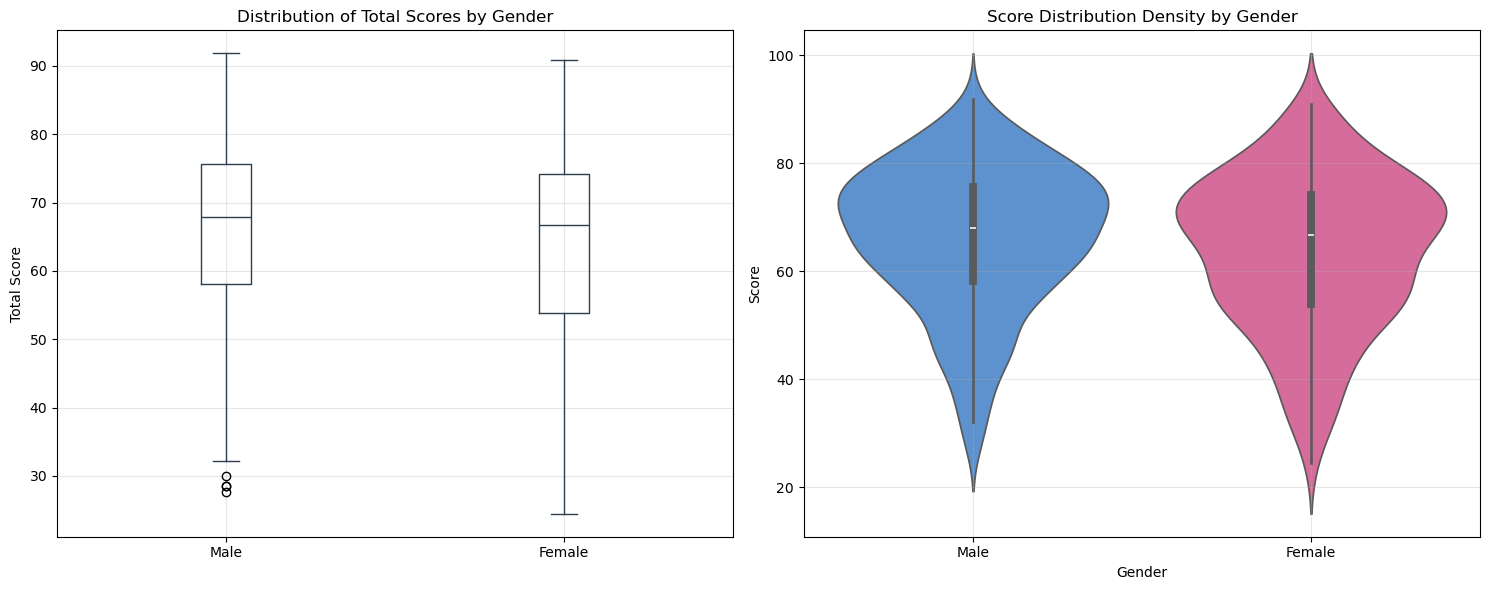

In [121]:
# Enhanced boxplot analysis with outlier identification
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Score outliers
df_outliers = pd.DataFrame({
    'Male': df_male['total_score'],
    'Female': df_female['total_score']
})

boxplot1 = df_outliers.boxplot(ax=ax1, return_type='dict', color=COLOR_BOXPLOT)
ax1.set_title('Distribution of Total Scores by Gender')
ax1.set_ylabel('Total Score')
ax1.grid(True, alpha=0.3)

# Identify outliers using IQR method
def identify_outliers(data, name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"{name}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Range: {outliers.min():.2f} - {outliers.max():.2f}")
    return outliers

print("=== OUTLIER ANALYSIS ===")
male_outliers = identify_outliers(df_male['total_score'], "Male")
female_outliers = identify_outliers(df_female['total_score'], "Female")

# Violin plot for better distribution visualization
df_melted = pd.melt(df_outliers.reset_index(), id_vars='index', 
                    value_vars=['Male', 'Female'], 
                    var_name='Gender', value_name='Score')
df_melted = df_melted.dropna()

sns.violinplot(data=df_melted, x='Gender', y='Score', hue='Gender', ax=ax2, 
               palette={'Male': COLOR_MALE, 'Female': COLOR_FEMALE}, legend=False)
ax2.set_title('Score Distribution Density by Gender')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Time-Performance Correlation Analysis

This section examines the relationship between time spent on the exam and performance, analyzing:
- Overall correlation between time and scores
- Gender-specific time-score relationships
- Statistical significance and practical implications

### 5.1 Correlation Analysis

In [122]:
print("=== TIME-SCORE CORRELATION ANALYSIS ===")

# Test normality for overall correlation
time_score_normal = test_correlation_normality(df_time['time_taken'], df_time['total_score'], 
                                             'Time taken', 'Total score')

# Choose appropriate correlation test based on normality
if time_score_normal:
    print(f"\nUsing PARAMETRIC approach (Pearson correlation):")
    primary_corr, primary_p = pearsonr(df_time['time_taken'], df_time['total_score'])
    primary_name = "Pearson correlation"
    primary_symbol = "r"
    
    # Also calculate Spearman as supplementary
    spearman_corr, spearman_p = spearmanr(df_time['time_taken'], df_time['total_score'])
    print(f"  {primary_name}: {primary_symbol} = {primary_corr:.4f}, p = {primary_p:.4f}")
    print(f"  Spearman correlation (supplementary): ρ = {spearman_corr:.4f}, p = {spearman_p:.4f}")
else:
    print(f"\nUsing NON-PARAMETRIC approach (Spearman correlation):")
    primary_corr, primary_p = spearmanr(df_time['time_taken'], df_time['total_score'])
    primary_name = "Spearman correlation"
    primary_symbol = "ρ"
    
    # Also calculate Pearson as supplementary (though not recommended for non-normal data)
    pearson_corr, pearson_p = pearsonr(df_time['time_taken'], df_time['total_score'])
    print(f"  {primary_name}: {primary_symbol} = {primary_corr:.4f}, p = {primary_p:.4f}")
    print(f"  Pearson correlation (supplementary): r = {pearson_corr:.4f}, p = {pearson_p:.4f}")

# Interpretation based on primary test
if abs(primary_corr) < 0.1:
    strength = "negligible"
elif abs(primary_corr) < 0.3:
    strength = "weak"
elif abs(primary_corr) < 0.5:
    strength = "moderate"
elif abs(primary_corr) < 0.7:
    strength = "strong"
else:
    strength = "very strong"

direction = "positive" if primary_corr > 0 else "negative"

print(f"\nPRIMARY INTERPRETATION ({primary_name}):")
print(f"  Correlation strength: {strength} {direction} correlation")
print(f"  Statistical significance: {'Yes' if primary_p < 0.05 else 'No'} (p = {primary_p:.4f})")
if time_score_normal:
    print(f"  Shared variance: {primary_corr**2:.1%}")

# Gender-specific correlations with normality testing
print(f"\n=== GENDER-SPECIFIC CORRELATIONS ===")

male_time_data = df_time[df_time['gender'] == 'M']
female_time_data = df_time[df_time['gender'] == 'F']

# Test normality for male data
male_normal = test_correlation_normality(male_time_data['time_taken'], male_time_data['total_score'],
                                       'Male time taken', 'Male total score')

# Test normality for female data  
female_normal = test_correlation_normality(female_time_data['time_taken'], female_time_data['total_score'],
                                         'Female time taken', 'Female total score')

# Calculate correlations based on normality results
if male_normal:
    male_corr, male_p = pearsonr(male_time_data['time_taken'], male_time_data['total_score'])
    male_test = "Pearson"
    male_symbol = "r"
else:
    male_corr, male_p = spearmanr(male_time_data['time_taken'], male_time_data['total_score'])
    male_test = "Spearman"
    male_symbol = "ρ"

if female_normal:
    female_corr, female_p = pearsonr(female_time_data['time_taken'], female_time_data['total_score'])
    female_test = "Pearson"
    female_symbol = "r"
else:
    female_corr, female_p = spearmanr(female_time_data['time_taken'], female_time_data['total_score'])
    female_test = "Spearman"  
    female_symbol = "ρ"

print(f"\nGender-specific results:")
print(f"  Male ({male_test}): {male_symbol} = {male_corr:.4f}, p = {male_p:.4f}")
print(f"  Female ({female_test}): {female_symbol} = {female_corr:.4f}, p = {female_p:.4f}")

=== TIME-SCORE CORRELATION ANALYSIS ===

Testing normality for Time taken and Total score:

Time taken (n=569):
  Shapiro-Wilk test for samples between 200 and 2000 entities: W=0.9080, p=0.0000
  Normal distribution: False

Total score (n=569):
  Shapiro-Wilk test for samples between 200 and 2000 entities: W=0.9709, p=0.0000
  Normal distribution: False

Both variables normally distributed: False

Using NON-PARAMETRIC approach (Spearman correlation):
  Spearman correlation: ρ = -0.1349, p = 0.0013
  Pearson correlation (supplementary): r = -0.0839, p = 0.0456

PRIMARY INTERPRETATION (Spearman correlation):
  Correlation strength: weak negative correlation
  Statistical significance: Yes (p = 0.0013)

=== GENDER-SPECIFIC CORRELATIONS ===

Testing normality for Male time taken and Male total score:

Male time taken (n=311):
  Shapiro-Wilk test for samples between 200 and 2000 entities: W=0.9374, p=0.0000
  Normal distribution: False

Male total score (n=311):
  Shapiro-Wilk test for samp

### 5.2 Correlation Results Interpretation

The following interpretation explains the time-score relationship findings in accessible language:

In [123]:
# User-friendly explanation of time-score correlation results
def explain_time_score_correlation_for_non_statisticians(time_data, score_data, overall_corr, overall_p, 
                                                        male_corr, male_p, female_corr, female_p,
                                                        primary_test_name):
    """
    Explain time-score correlation results in plain, accessible language for non-statisticians
    """
    print("UNDERSTANDING TIME-SCORE RELATIONSHIP RESULTS")
    print("=" * 70)
    
    # Basic descriptive information
    avg_time = np.mean(time_data)
    avg_score = np.mean(score_data)
    
    print(f"\n BASIC INFORMATION:")
    print(f"   • Average exam time: {avg_time:.1f} minutes")
    print(f"   • Average exam score: {avg_score:.1f} points")
    print(f"   • Total students analyzed: {len(time_data)}")
    
    # Question 1: Is there a relationship between time and performance?
    print(f"\n QUESTION 1: Is there a relationship between TIME SPENT and PERFORMANCE?")
    
    # Interpret correlation strength
    abs_corr = abs(overall_corr)
    if abs_corr < 0.1:
        strength_desc = "virtually no relationship"
        practical_meaning = "Time spent has almost no connection to exam scores"
    elif abs_corr < 0.3:
        strength_desc = "a weak relationship" 
        practical_meaning = "Time spent has a small connection to exam scores"
    elif abs_corr < 0.5:
        strength_desc = "a moderate relationship"
        practical_meaning = "Time spent has a noticeable connection to exam scores"
    elif abs_corr < 0.7:
        strength_desc = "a strong relationship"
        practical_meaning = "Time spent has a clear connection to exam scores"
    else:
        strength_desc = "a very strong relationship"
        practical_meaning = "Time spent has a very strong connection to exam scores"
    
    # Determine direction
    if overall_corr > 0:
        direction_desc = "Students who spend MORE time tend to score HIGHER"
        time_advice = "Taking more time generally leads to better performance"
    elif overall_corr < 0:
        direction_desc = "Students who spend MORE time tend to score LOWER" 
        time_advice = "Taking more time is associated with lower performance (may indicate struggling)"
    else:
        direction_desc = "No clear pattern between time and scores"
        time_advice = "Time spent doesn't clearly predict performance"
    
    print(f"   ANSWER: There is {strength_desc}")
    print(f"   Direction: {direction_desc}")
    print(f"   What this means: {practical_meaning}")
    
    # Statistical reliability
    if overall_p < 0.001:
        reliability = "extremely reliable (99.9%+ confidence)"
    elif overall_p < 0.01:
        reliability = "very reliable (99%+ confidence)"
    elif overall_p < 0.05:
        reliability = "reliable (95%+ confidence)"
    elif overall_p < 0.10:
        reliability = "somewhat uncertain (90% confidence)"
    else:
        reliability = "not reliable (could be due to chance)"
    
    print(f"   Reliability: This finding is {reliability}")
    
    # Question 2: Practical implications
    print(f"\n QUESTION 2: What does this mean for EXAM STRATEGY?")
    
    if overall_p >= 0.05:
        print(f"   STRATEGY: Time management may not significantly impact scores")
        print(f"   • Focus on preparation quality rather than time spent during exam")
        print(f"   • Individual pacing preferences matter more than following a specific time strategy")
        
    elif abs_corr < 0.3:
        print(f"   STRATEGY: Time has a small but real effect on performance")
        print(f"   • {time_advice}")
        
    elif overall_corr > 0.3:
        print(f"   STRATEGY: Taking adequate time appears beneficial") 
        print(f"   • Students should avoid rushing through the exam")
        print(f"   • Encourage thorough review and careful problem-solving")
        print(f"   • Time management training might help improve scores")
        
    elif overall_corr < -0.3:
        print(f"   STRATEGY: Longer time may indicate difficulty, not better strategy")
        print(f"   • Students spending much longer may be struggling with material")
        print(f"   • Focus on improving understanding rather than just time management")
        print(f"   • Consider additional support for students who consistently take much longer")
    
    # Question 3: Gender differences
    print(f"\n QUESTION 3: Are there GENDER DIFFERENCES in the time-score relationship?")
    
    # Compare male and female correlations
    if abs(male_corr - female_corr) < 0.1:
        gender_diff = "very similar"
        gender_meaning = "Time affects male and female performance in nearly the same way"
        # gender_advice = "Use the same time management strategies for all students"
    elif abs(male_corr - female_corr) < 0.3:
        gender_diff = "somewhat different"
        if abs(male_corr) > abs(female_corr):
            stronger_group = "male"
            weaker_group = "female"
        else:
            stronger_group = "female"
            weaker_group = "male"
        gender_meaning = f"Time has a stronger effect on {stronger_group} student performance"
        # gender_advice = f"Consider if {stronger_group} students need different time management guidance"
    else:
        gender_diff = "quite different"
        if abs(male_corr) > abs(female_corr):
            stronger_group = "male"
            weaker_group = "female"
        else:
            stronger_group = "female" 
            weaker_group = "male"
        gender_meaning = f"Time has a much stronger effect on {stronger_group} student performance"
        # gender_advice = f"Strongly consider gender-specific time management strategies"
    
    print(f"   ANSWER: The time-score relationship is {gender_diff} between genders")
    print(f"   Male correlation: {male_corr:.3f} (p = {male_p:.3f})")
    print(f"   Female correlation: {female_corr:.3f} (p = {female_p:.3f})")
    print(f"   What this means: {gender_meaning}")
    # print(f"   Recommendation: {gender_advice}")

    
    if abs(male_corr - female_corr) >= 0.2:
        print(f"   4. Consider gender-specific time management guidance")
    
    print(f"\n" + "=" * 70)

# Call the explanation function with our correlation results
explain_time_score_correlation_for_non_statisticians(
    df_time['time_taken'], df_time['total_score'], 
    primary_corr, primary_p,
    male_corr, male_p, female_corr, female_p,
    primary_name
)

UNDERSTANDING TIME-SCORE RELATIONSHIP RESULTS

 BASIC INFORMATION:
   • Average exam time: 200.5 minutes
   • Average exam score: 64.9 points
   • Total students analyzed: 569

 QUESTION 1: Is there a relationship between TIME SPENT and PERFORMANCE?
   ANSWER: There is a weak relationship
   Direction: Students who spend MORE time tend to score LOWER
   What this means: Time spent has a small connection to exam scores
   Reliability: This finding is very reliable (99%+ confidence)

 QUESTION 2: What does this mean for EXAM STRATEGY?
   STRATEGY: Time has a small but real effect on performance
   • Taking more time is associated with lower performance (may indicate struggling)

 QUESTION 3: Are there GENDER DIFFERENCES in the time-score relationship?
   ANSWER: The time-score relationship is somewhat different between genders
   Male correlation: -0.046 (p = 0.424)
   Female correlation: -0.200 (p = 0.001)
   What this means: Time has a stronger effect on female student performance



### 5.3 Time Analysis Visualizations

The following visualizations examine time usage patterns by gender and their relationship with exam performance.

#### 5.3.1 Time Statistics by Gender

In [124]:
# Time analysis descriptive statistics
time_stats = pd.DataFrame([
    calculate_descriptive_stats(df_time[df_time['gender'] == 'M']['time_taken'], 'Male'),
    calculate_descriptive_stats(df_time[df_time['gender'] == 'F']['time_taken'], 'Female')
]).T

print("=== TIME ANALYSIS DESCRIPTIVE STATISTICS ===")
print(time_stats)

=== TIME ANALYSIS DESCRIPTIVE STATISTICS ===
             Male   Female
Count     311.000  258.000
Mean      190.500  212.580
Median    198.780  228.690
Mode      240.030  240.070
Std Dev    47.870   37.750
Min        40.750   81.930
Max       278.280  297.530
Q1        159.680  195.760
Q3        234.360  239.120
IQR        74.680   43.360
Skewness   -0.680   -1.106
Kurtosis   -0.246    0.700


#### 5.3.2 Time Distribution and Time-Score Relationship Plots

The following visualizations provide different perspectives on time usage:
1. **Boxplot**: Time distribution by gender with outlier identification
2. **Scatter plot**: Time vs score relationship by gender

=== TIME OUTLIER ANALYSIS ===
Male Time: 1 outliers (0.3%)
  Range: 40.75 - 40.75
Female Time: 9 outliers (3.5%)
  Range: 81.93 - 130.53


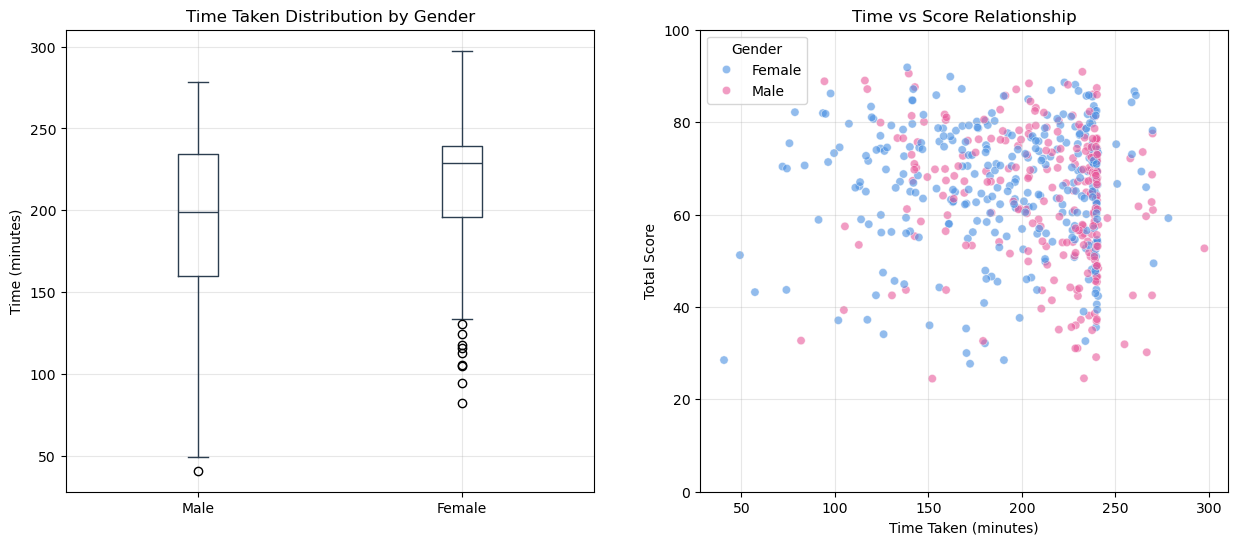

<Figure size 640x480 with 0 Axes>

In [125]:
# Enhanced time analysis visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Time taken boxplot
df_time_clean = df_time.dropna(subset=['time_taken'])
df_time_outliers = pd.DataFrame({
    'Male': df_time_clean[df_time_clean['gender'] == 'M']['time_taken'],
    'Female': df_time_clean[df_time_clean['gender'] == 'F']['time_taken']
})

df_time_outliers.boxplot(ax=axes[0], return_type='dict', color=COLOR_BOXPLOT)
axes[0].set_title("Time Taken Distribution by Gender")
axes[0].set_ylabel("Time (minutes)")
axes[0].grid(True, alpha=0.3)

# Time outlier analysis
print("=== TIME OUTLIER ANALYSIS ===")
time_male_outliers = identify_outliers(df_time_clean[df_time_clean['gender'] == 'M']['time_taken'], "Male Time")
time_female_outliers = identify_outliers(df_time_clean[df_time_clean['gender'] == 'F']['time_taken'], "Female Time")

# Time vs Score relationship
sns.scatterplot(data=df_time_clean, x='time_taken', y='total_score', 
               hue='gender', alpha=0.6, ax=axes[1],
               palette={'F': COLOR_FEMALE, 'M': COLOR_MALE})
axes[1].set_title("Time vs Score Relationship")
axes[1].set_xlabel("Time Taken (minutes)")
axes[1].set_ylabel("Total Score")
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)
# Update legend labels for clarity
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['Female', 'Male'], title='Gender')


plt.show()
plt.tight_layout()